<a href="https://colab.research.google.com/github/DHRUVCHARNE/AI-Learn-Notebooks/blob/main/build_makemore_manual_backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [279]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [280]:
# read in all the words
words = open('/content/names.txt','r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:5])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [281]:
# build the vocabulary
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [282]:
# build the dataset
block_size = 4  # How many characters do we take to predict the next one?
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0]*block_size
    for ch in w+'.':
      ix=stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:]+[ix]
  X = torch.tensor(X)
  Y= torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y
import random
random.seed(41)
random.shuffle(words)
n1 = int(0.8*len(words))
n2= int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


torch.Size([182397, 4]) torch.Size([182397])
torch.Size([22905, 4]) torch.Size([22905])
torch.Size([22844, 4]) torch.Size([22844])


In [283]:
# utility function we will use later when comparing manual gradients
def cmp(s,dt,t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt,t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate:{str(app):5s} | maxdiff: {maxdiff}')

In [284]:
n_embd = 16
n_hidden = 64
g=torch.Generator().manual_seed(2147483647)
# Embedding
C = torch.randn((vocab_size,n_embd),generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size,n_hidden),generator=g) * (5/3) * ((n_embd * block_size)**0.5)
b1=torch.randn(n_hidden,generator=g) * 0.1 # Just for fun useless because of batch normalization
# Layer 2
W2 = torch.randn((n_hidden,vocab_size),generator = g) *0.1
b2 = torch.randn(vocab_size,generator=g)*0.1
# BatchNorm Parameters
bngain = torch.randn((1,n_hidden))*0.1 + 1.0
bnbias = torch.randn((1,n_hidden))*0.1

# Note I am initializing many of these parameters in non-standars ways
# because sometimes initializing with e.g. all zeros could mask an
# incorrect implementation of the backward pass
parameters = [C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True


6475


In [285]:
batch_size = 32
n =batch_size # shorter variable for convenience
# construct a minibatch
ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
Xb,Yb = Xtr[ix],Ytr[ix] # Batch X ,Y

In [286]:
# Forward pass
emb = C[Xb]
embcat = emb.view(emb.shape[0],-1) # Concatenate the vectors
# Linear Layer 1
hprebn = embcat @ W1 + b1 # hidden layer preactivation
# Batch Norm Layer
bnmeani = 1 / n*hprebn.sum(0,keepdim=True)
bndiff=hprebn -bnmeani
bndiff2 = bndiff**2
bnvar = 1 / (n-1)*(bndiff2).sum(0,keepdim=True) # Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact= bngain * bnraw + bnbias
# Non Linearity
h = torch.tanh(hpreact)
# Linear Layer 2
logits = h @ W2 + b2
# Cross Entropy loss same as F.cross_entropy(logits,Yb)
logit_maxes = logits.max(1,keepdim=True).values
norm_logits = logits - logit_maxes # Subtract Max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1,keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv # If I use (1.0 / counts_sum) instead then I can't get backprop exact
logprobs = probs.log()
loss = -logprobs[range(n),Yb].mean()
# Pytorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs,probs,counts,counts_sum,counts_sum_inv,norm_logits,
          logit_maxes,logits,h,hpreact,bnraw,bnvar,bnvar_inv,bndiff,bndiff2,
          hprebn,bnmeani,embcat,emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.4183, grad_fn=<NegBackward0>)

In [287]:
# Backprop through the whole thing manually

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n),Yb] = -1.0 / n
cmp('logprobs',dlogprobs,logprobs)
dprobs = (1.0/probs)*dlogprobs
cmp('probs',dprobs,probs)
dcounts_sum_inv = (counts * dprobs).sum(1,keepdim=True)
cmp('counts_sum_inv',dcounts_sum_inv,counts_sum_inv)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum',dcounts_sum,counts_sum)
dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts',dcounts,counts) # Now counts gets the two contributions
dnorm_logits = counts  * dcounts
cmp('norm_logits',dnorm_logits,norm_logits)
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1,keepdim=True)
cmp('logit_maxes',dlogit_maxes,logit_maxes)
dlogits += F.one_hot(logits.max(1).indices,num_classes=logits.shape[1]) * dlogit_maxes
cmp('logits',dlogits,logits)
dh = dlogits @ W2.T
cmp('h',dh,h)
dW2 = h.T @ dlogits
cmp('W2',dW2,W2)
db2 = dlogits.sum(0,keepdim=True)
cmp('b2',db2,b2)
dhpreact = (1 - h**2)*dh
cmp('hpreact',dhpreact,hpreact)
dbngain = (bnraw * dhpreact).sum(0,keepdim=True)
cmp('dbngain',dbngain,bngain)
dbnraw = bngain * dhpreact
cmp('dbnraw',dbnraw,bnraw)
dbnbias = dhpreact.sum(0,keepdim=True)
cmp('dbnbias',dbnbias,bnbias)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0,keepdim=True)
cmp('dbnvar_inv',dbnvar_inv,bnvar_inv)
dbnvar=(-0.5*(bnvar+1e-5)**-1.5)*dbnvar_inv
cmp('dbnvar',dbnvar,bnvar)
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2)*dbnvar
cmp('dbndiff2',dbndiff2,bndiff2)
dbndiff+=(2*bndiff)*(dbndiff2)
cmp('bndiff',dbndiff,bndiff)
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0,keepdim=True)
cmp('dbnmeani',dbnmeani,bnmeani)
dhprebn+= 1.0/n * (torch.ones_like(hprebn)*dbnmeani)
cmp('hprebn',dhprebn,hprebn)
dembcat = dhprebn @ W1.T
cmp('embcat',dembcat,embcat)
dW1 = embcat.T @ dhprebn
cmp('W1',dW1,W1)
db1=dhprebn.sum(0,keepdim=True)
cmp('b1',db1,b1)
demb=dembcat.view(emb.shape)
cmp('emb',demb,emb)
dC=torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix=Xb[k,j]
    dC[ix]+=demb[k,j]
cmp('C',dC,C)

logprobs        | exact: True  | approximate:True  | maxdiff: 0.0
probs           | exact: True  | approximate:True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate:True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate:True  | maxdiff: 0.0
counts          | exact: True  | approximate:True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate:True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate:True  | maxdiff: 0.0
logits          | exact: True  | approximate:True  | maxdiff: 0.0
h               | exact: True  | approximate:True  | maxdiff: 0.0
W2              | exact: True  | approximate:True  | maxdiff: 0.0
b2              | exact: True  | approximate:True  | maxdiff: 0.0
hpreact         | exact: False | approximate:True  | maxdiff: 9.313225746154785e-10
dbngain         | exact: False | approximate:True  | maxdiff: 1.862645149230957e-09
dbnraw          | exact: False | approximate:True  | maxdiff: 9.313225746154785e-10
dbnbias         | exac

In [288]:
# now
loss_fast = F.cross_entropy(logits,Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.418274402618408 diff: 0.0


In [289]:
# backward pass
# Using the p_i-y_i for derivative of cross entropy loss
# to simplify the calculation above
dlogits = F.softmax(logits,1) # applying along 1 the class dimension
dlogits[range(n),Yb]-=1
dlogits/=n
cmp('logits',dlogits,logits)

logits          | exact: False | approximate:True  | maxdiff: 6.05359673500061e-09


In [290]:
F.softmax(logits,1)[0]

tensor([0.0164, 0.0302, 0.0558, 0.0308, 0.0259, 0.0342, 0.0597, 0.0159, 0.0845,
        0.0411, 0.0468, 0.0293, 0.0221, 0.0326, 0.0394, 0.0215, 0.0255, 0.0543,
        0.0412, 0.0146, 0.0632, 0.0428, 0.0312, 0.0139, 0.0356, 0.0367, 0.0547],
       grad_fn=<SelectBackward0>)

In [291]:
dlogits[0] * n

tensor([ 0.0164,  0.0302,  0.0558,  0.0308,  0.0259,  0.0342,  0.0597,  0.0159,
         0.0845,  0.0411,  0.0468,  0.0293,  0.0221,  0.0326, -0.9606,  0.0215,
         0.0255,  0.0543,  0.0412,  0.0146,  0.0632,  0.0428,  0.0312,  0.0139,
         0.0356,  0.0367,  0.0547], grad_fn=<MulBackward0>)

In [292]:
dlogits[0].sum()

tensor(-1.1642e-09, grad_fn=<SumBackward0>)

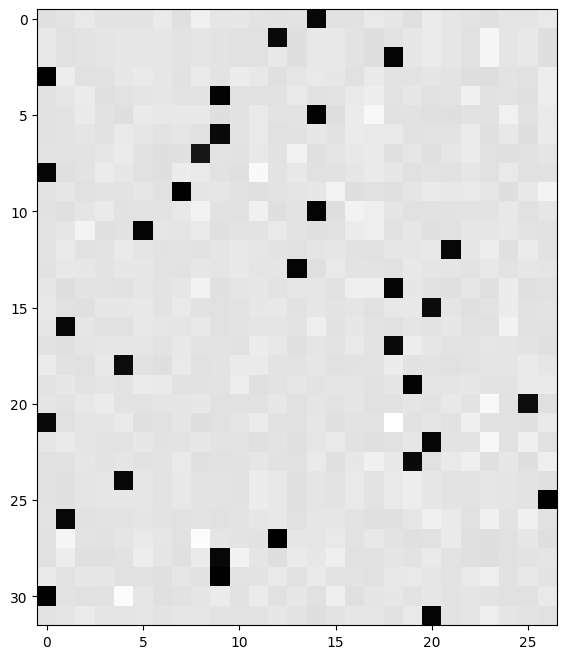

In [293]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(),cmap='gray')

In [294]:
dhprebn=bngain*bnvar_inv/n*(n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn',dhprebn,hprebn)

hprebn          | exact: False | approximate:True  | maxdiff: 1.4551915228366852e-11


In [295]:
import math

In [296]:
# Putting it all together
n_embd = 16
n_hidden = 600
g=torch.Generator().manual_seed(2147483647)
# Embedding
C = torch.randn((vocab_size,n_embd),generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size,n_hidden),generator=g) * (5/3) * ((n_embd * block_size)**0.5)
b1=torch.randn(n_hidden,generator=g) * 0.1 # Just for fun useless because of batch normalization
# Layer 2
W2 = torch.randn((n_hidden,vocab_size),generator = g) *0.1
b2 = torch.randn(vocab_size,generator=g)*0.1
# BatchNorm Parameters
bngain = torch.randn((1,n_hidden))*0.1 + 1.0
bnbias = torch.randn((1,n_hidden))*0.1

# Note I am initializing many of these parameters in non-standars ways
# because sometimes initializing with e.g. all zeros could mask an
# incorrect implementation of the backward pass
parameters = [C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True
# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []


  # kick off optimization
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.01 if i < 100000 else 0.001 # step learning rate decay
    for p, grad in zip(parameters, grads):
      # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    #   break

56859
      0/ 200000: 4.1544
  10000/ 200000: 2.5223
  20000/ 200000: 2.5505
  30000/ 200000: 2.1459
  40000/ 200000: 2.3521
  50000/ 200000: 2.1794
  60000/ 200000: 1.9412
  70000/ 200000: 2.2764
  80000/ 200000: 2.2440
  90000/ 200000: 1.9666
 100000/ 200000: 2.4918
 110000/ 200000: 1.9334
 120000/ 200000: 2.0033
 130000/ 200000: 1.6369
 140000/ 200000: 2.2861
 150000/ 200000: 2.0341
 160000/ 200000: 1.8601
 170000/ 200000: 2.5950
 180000/ 200000: 2.2523
 190000/ 200000: 2.1230


In [297]:
#useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [298]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [299]:

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1255946159362793
val 2.152930974960327


In [300]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
amelle.
khiem.
shreytl.
salaysa.
jazonen.
deliah.
jarqui.
nelesia.
chaiiv.
kaleigh.
hama.
kindee.
juharline.
livebi.
wattho.
dearixita.
jenni.
sabee.
deco.
